In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [118]:

# 1. Define a simple linear model
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [119]:
# 2. Generate synthetic data
X = torch.randn(100, 1) * 10 # 100 data points, 1 feature
y = 2 * X + 3 + torch.randn(100, 1) * 2 # y = 2x + 3 + noise

In [120]:
criterion = nn.MSELoss()
learning_rate = 0.001
epochs = 100

Epoch [10/100], Loss: 19.4548
Epoch [20/100], Loss: 16.6576
Epoch [30/100], Loss: 16.1954
Epoch [40/100], Loss: 15.7628
Epoch [50/100], Loss: 15.3466
Epoch [60/100], Loss: 14.9461
Epoch [70/100], Loss: 14.5607
Epoch [80/100], Loss: 14.1899
Epoch [90/100], Loss: 13.8331
Epoch [100/100], Loss: 13.4897


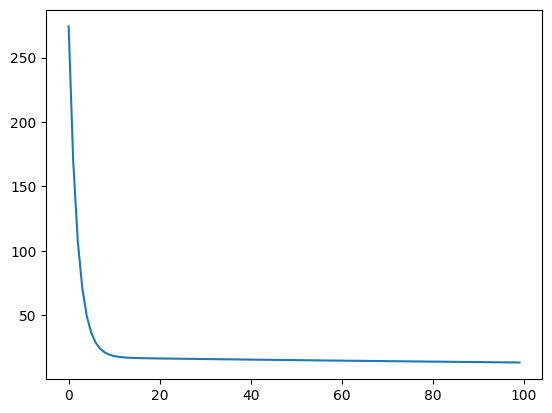

In [121]:
# --- Batch Gradient Descent (BGD) ---
model_bgd = LinearRegression()
optimizer_bgd = optim.SGD(model_bgd.parameters(), lr=learning_rate)

bgd_loss = []

for epoch in range(epochs):
    # Forward pass
    predictions = model_bgd(X)
    loss = criterion(predictions, y)

    # Backward and optimize
    optimizer_bgd.zero_grad()
    loss.backward()
    optimizer_bgd.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    bgd_loss.append(loss.item())

plt.plot(range(len(bgd_loss)), bgd_loss)


--- Stochastic Gradient Descent ---


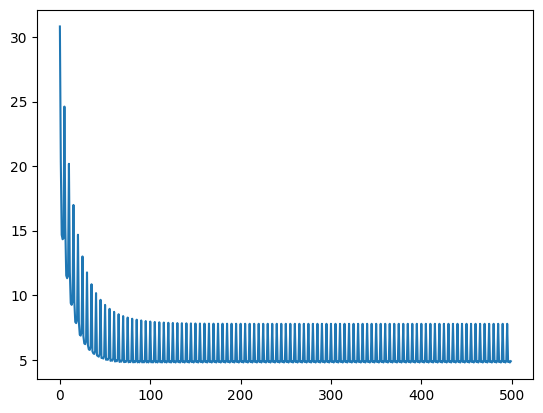

In [122]:
# --- Stochastic Gradient Descent (SGD) ---
print("\n--- Stochastic Gradient Descent ---")
model_sgd = LinearRegression()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=learning_rate)

sgd_loss = []

for epoch in range(epochs):
    # Iterate over individual data points
    for i in range(len(X)):
        x_i, y_i = X[i], y[i]

        # Forward pass
        prediction = model_sgd(x_i)
        loss = criterion(prediction, y_i)

        # Backward and optimize
        optimizer_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()

        if (i + 1) % 20 == 0:
            # Calculate loss over entire dataset for reporting
          with torch.no_grad():
              total_loss = criterion(model_sgd(X), y).item()
          sgd_loss.append(total_loss)


plt.plot(range(len(sgd_loss)), sgd_loss)


--- Mini-Batch Gradient Descent ---
Epoch [10/100], Loss: 9.3388
Epoch [20/100], Loss: 8.2090
Epoch [30/100], Loss: 7.3955
Epoch [40/100], Loss: 6.7684
Epoch [50/100], Loss: 6.3318
Epoch [60/100], Loss: 5.9654
Epoch [70/100], Loss: 5.6630
Epoch [80/100], Loss: 5.5207
Epoch [90/100], Loss: 5.2964
Epoch [100/100], Loss: 5.1990


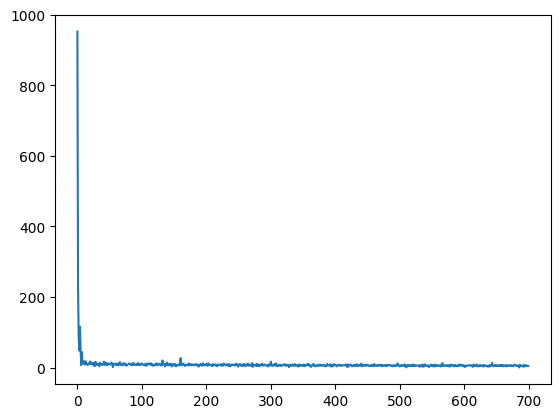

In [123]:
# --- Mini-Batch Gradient Descent (MBGD) ---
print("\n--- Mini-Batch Gradient Descent ---")
model_mbgd = LinearRegression()
batch_size = 16
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer_mbgd = optim.SGD(model_mbgd.parameters(), lr=learning_rate)

mbgd_loss = []

for epoch in range(epochs):
    for batch_X, batch_y in dataloader:
        # Forward pass
        predictions = model_mbgd(batch_X)
        loss = criterion(predictions, batch_y)

        # Backward and optimize
        optimizer_mbgd.zero_grad()
        loss.backward()
        optimizer_mbgd.step()

        mbgd_loss.append(loss.item())

    if (epoch + 1) % 10 == 0:
        # Calculate loss over entire dataset for reporting
        with torch.no_grad():
            total_loss = criterion(model_mbgd(X), y).item()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}')

plt.plot(range(len(mbgd_loss)), mbgd_loss)